# Plot PDF of Convective Cell lifetime

C:\Users\msmillan\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded data from filtered_free_cells_202105_1km.csv with 1770 rows.
Error reading filtered_free_cells_202106_1km.csv: [Errno 2] No such file or directory: 'filtered_free_cells_202106_1km.csv'
Loaded data from filtered_free_cells_202107_1km.csv with 1033 rows.
Loaded data from filtered_free_cells_202108_1km.csv with 19640 rows.
Loaded data from filtered_free_cells_202109_1km.csv with 9310 rows.
Loaded data from filtered_free_cells_202205_1km.csv with 2098 rows.
Loaded data from filtered_free_cells_202206_1km.csv with 4816 rows.
Loaded data from filtered_free_cells_202207_1km.csv with 12177 rows.
Loaded data from filtered_free_cells_202208_1km.csv with 23665 rows.
Loaded data from filtered_free_cells_202209_1km.csv with 11799 rows.
Loaded data from filtered_free_cells_202305_1km.csv with 6816 rows.
Loaded data from filtered_free_cells_202306_1km.csv with 4226 rows.
Loaded data from filtered_free_cells_202307_1km.csv with 9113 rows.
Loaded data from filtered_free_cells_202308_1km.csv with

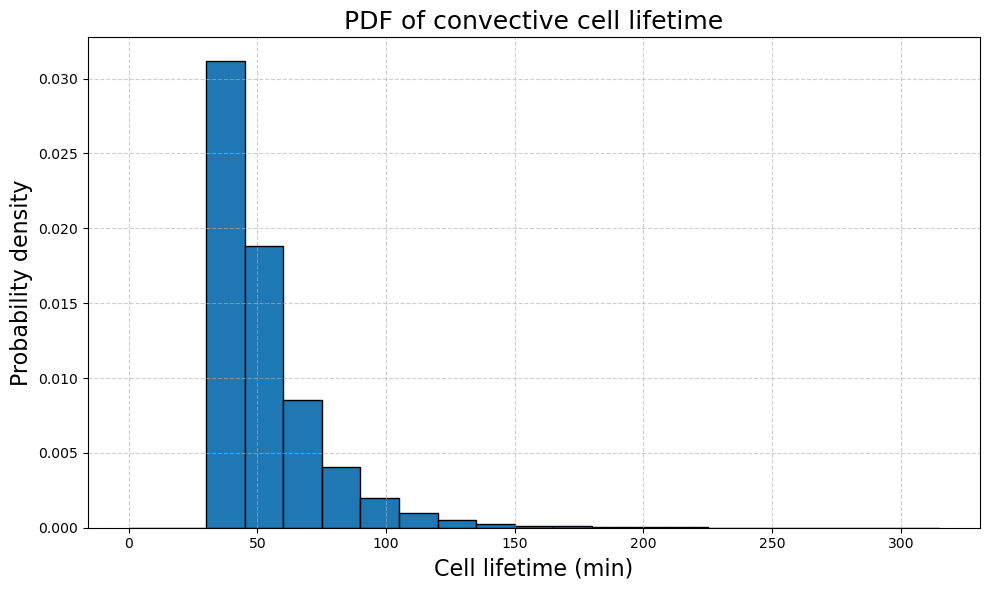

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Define years and months
# ----------------------------
years = ["2021", "2022", "2023", "2024"]
months = ["05", "06", "07", "08", "09"]

# ----------------------------
# Load all CSVs and combine
# ----------------------------
dfs = []
for year in years:
    for month in months:
        csv_file = f"filtered_free_cells_{year}{month}_1km.csv"
        try:
            df_month = pd.read_csv(csv_file)
            print(f"Loaded data from {csv_file} with {len(df_month)} rows.")
            df_month["year"] = year
            df_month["month"] = month
            # unique cell id across all files
            df_month["unique_cell"] = (
                df_month["year"] + "_" + df_month["month"] + "_" + df_month["cell"].astype(str)
            )
            dfs.append(df_month)
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")

if not dfs:
    raise ValueError("No data loaded. Check your file paths and names.")

df = pd.concat(dfs, ignore_index=True)
print(f"Combined dataset has {len(df)} rows.")

# ----------------------------
# Compute lifetime per cell (minutes) from time_cell
# ----------------------------
df["time_cell"] = pd.to_timedelta(df["time_cell"])
df["time_minutes"] = df["time_cell"].dt.total_seconds() / 60.0

cell_lifetime = (
    df.groupby("unique_cell")["time_minutes"]
      .max()
      .rename("lifetime_min")
      .reset_index()
)

lifetimes = cell_lifetime["lifetime_min"].dropna().values
print(f"Number of unique cells: {len(lifetimes)}")
print(f"Lifetime range (min): {np.nanmin(lifetimes):.1f} to {np.nanmax(lifetimes):.1f}")

# ----------------------------
# Plot PDF of lifetime (continuous density)
# ----------------------------
bin_width = 15  # minutes (matches your earlier binning)
max_life = np.ceil(np.nanmax(lifetimes) / bin_width) * bin_width
bins = np.arange(0, max_life + bin_width, bin_width)

plt.figure(figsize=(10, 6))
plt.hist(lifetimes, bins=bins, density=True, edgecolor="black")
plt.xlabel("Cell lifetime (min)", fontsize=16)
plt.ylabel("Probability density", fontsize=16)
plt.title("PDF of convective cell lifetime", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdf_cell_lifetime.png", dpi=300, bbox_inches="tight")
plt.show()
